<a href="https://colab.research.google.com/github/sachinadk2011/handwritten-alphanumeric-recognition/blob/main/handwritten_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/sachinadk2011/handwritten-alphanumeric-recognition/blob/main/handwritten_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout, Conv2D, MaxPooling2D, BatchNormalization
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# generators
train_ds  = keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/handwritten_english_character_and_digits/handwritten-english-characters-and-digits/combined_folder/train",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=42,
)

validation_ds =  keras.utils.image_dataset_from_directory(
    directory = "/content/drive/MyDrive/handwritten_english_character_and_digits/handwritten-english-characters-and-digits/combined_folder/test",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
)

Found 2728 files belonging to 62 classes.
Found 682 files belonging to 62 classes.


In [25]:
#normalize
def process(image, label):
    image = tf.cast(image/255., tf.float32)
    return image, label

In [26]:
train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [27]:
import os
import random
import numpy as np

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

tf.config.experimental.enable_op_determinism()

In [28]:
images, labels = next(iter(train_ds))
images.shape, labels.shape

(TensorShape([32, 128, 128, 3]), TensorShape([32]))

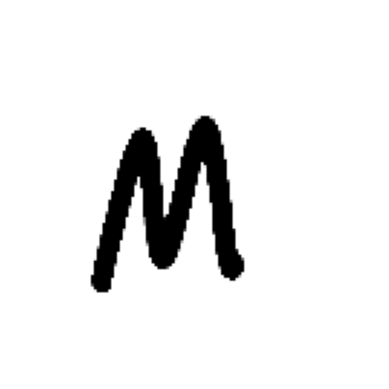

In [29]:
plt.imshow(images[2].numpy())
plt.axis('off')
plt.show()

In [30]:
#model 1
model1


<Sequential name=sequential_1, built=True>